
# ML Project Template
## Organized structure for code, data, and results
Use this notebook to write and run your ML code.


In [1]:
import torch
print("PyTorch GPU:", torch.cuda.is_available())

import tensorflow as tf
print("TensorFlow GPU:", tf.config.list_physical_devices('GPU'))


PyTorch GPU: True


2025-10-09 10:28:55.040333: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-09 10:28:55.040509: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-09 10:28:55.042790: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-09 10:28:55.255257: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-09 10:28:56.922574: W tensorflow/compiler/

TensorFlow GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2025-10-09 10:28:59.047754: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-09 10:28:59.191868: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-09 10:28:59.191941: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
import sys
print(sys.executable)       


/home/krish/skinvision-env/bin/python


In [3]:

# Example: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Path to your images folder (WSL format)
data_dir = "/mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_images"

# Optional: check a few files
import os
print(os.listdir(data_dir)[:10])  # prints first 10 images


['ISIC_0024306.jpg', 'ISIC_0024307.jpg', 'ISIC_0024308.jpg', 'ISIC_0024309.jpg', 'ISIC_0024310.jpg', 'ISIC_0024311.jpg', 'ISIC_0024312.jpg', 'ISIC_0024313.jpg', 'ISIC_0024314.jpg', 'ISIC_0024315.jpg']


In [5]:
import os

# Path to your dataset folder (WSL format)
data_dir = "/mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_images"

# List files / verify
print("Number of images:", len(os.listdir(data_dir)))
print("First 10 files:", os.listdir(data_dir)[:10])


Number of images: 10015
First 10 files: ['ISIC_0024306.jpg', 'ISIC_0024307.jpg', 'ISIC_0024308.jpg', 'ISIC_0024309.jpg', 'ISIC_0024310.jpg', 'ISIC_0024311.jpg', 'ISIC_0024312.jpg', 'ISIC_0024313.jpg', 'ISIC_0024314.jpg', 'ISIC_0024315.jpg']


Contents of the dataset folder:
📄 ISIC_0024306.jpg (0.3 MB)
📄 ISIC_0024307.jpg (0.3 MB)
📄 ISIC_0024308.jpg (0.3 MB)
📄 ISIC_0024309.jpg (0.3 MB)
📄 ISIC_0024310.jpg (0.4 MB)
📄 ISIC_0024311.jpg (0.3 MB)
📄 ISIC_0024312.jpg (0.2 MB)
📄 ISIC_0024313.jpg (0.2 MB)
📄 ISIC_0024314.jpg (0.3 MB)
📄 ISIC_0024315.jpg (0.3 MB)
📄 ISIC_0024316.jpg (0.3 MB)
📄 ISIC_0024317.jpg (0.3 MB)
📄 ISIC_0024318.jpg (0.3 MB)
📄 ISIC_0024319.jpg (0.3 MB)
📄 ISIC_0024320.jpg (0.3 MB)
📄 ISIC_0024321.jpg (0.3 MB)
📄 ISIC_0024322.jpg (0.3 MB)
📄 ISIC_0024323.jpg (0.3 MB)
📄 ISIC_0024324.jpg (0.2 MB)
📄 ISIC_0024325.jpg (0.3 MB)
📄 ISIC_0024326.jpg (0.3 MB)
📄 ISIC_0024327.jpg (0.3 MB)
📄 ISIC_0024328.jpg (0.3 MB)
📄 ISIC_0024329.jpg (0.2 MB)
📄 ISIC_0024330.jpg (0.2 MB)
📄 ISIC_0024331.jpg (0.2 MB)
📄 ISIC_0024332.jpg (0.2 MB)
📄 ISIC_0024333.jpg (0.2 MB)
📄 ISIC_0024334.jpg (0.3 MB)
📄 ISIC_0024335.jpg (0.3 MB)
📄 ISIC_0024336.jpg (0.2 MB)
📄 ISIC_0024337.jpg (0.3 MB)
📄 ISIC_0024338.jpg (0.2 MB)
📄 ISIC_0024339.jpg (0.3 MB)
📄 ISIC_0024340.j

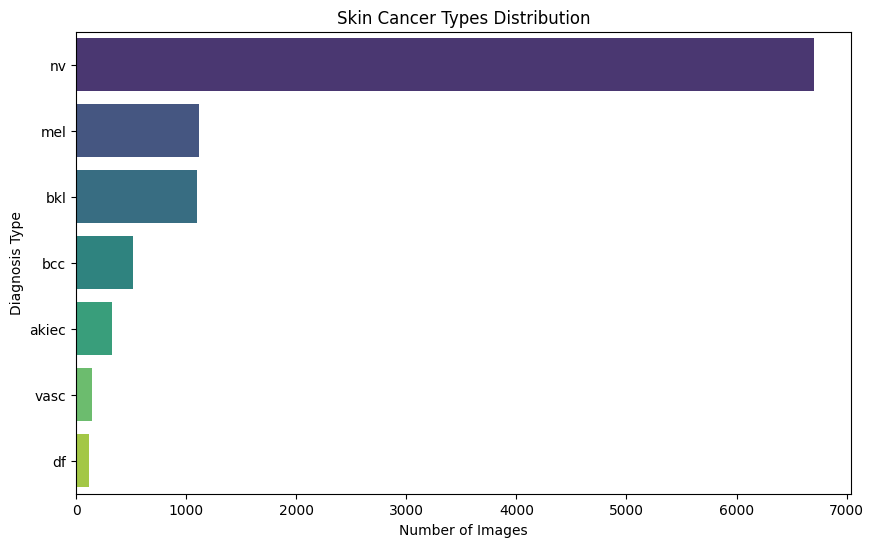

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Local dataset folder and metadata CSV
# Use data_dir for correct WSL path

# Use WSL-compatible path for metadata
metadata_path = "/mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_metadata.csv"

# 1️⃣ List contents of the dataset folder
print("Contents of the dataset folder:")
for item in os.listdir(data_dir):
    item_path = os.path.join(data_dir, item)
    if os.path.isfile(item_path):
        size = os.path.getsize(item_path) / (1024*1024)  # Size in MB
        print(f"📄 {item} ({size:.1f} MB)")
    else:
        num_files = len(os.listdir(item_path))
        print(f"📁 {item} ({num_files} files)")

# 2️⃣ Load metadata
metadata = pd.read_csv(metadata_path)

# 3️⃣ Check diagnosis distribution
dx_counts = metadata['dx'].value_counts()
print("\n" + "="*50)
print("DISEASE CLASS DISTRIBUTION:")
print("="*50)
for dx, count in dx_counts.items():
    percentage = (count / len(metadata)) * 100
    print(f"{dx}: {count} images ({percentage:.1f}%)")

# 4️⃣ Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=dx_counts.values, y=dx_counts.index, palette='viridis', hue=dx_counts.index, dodge=False, legend=False)


plt.title('Skin Cancer Types Distribution')
plt.xlabel('Number of Images')
plt.ylabel('Diagnosis Type')
plt.show()


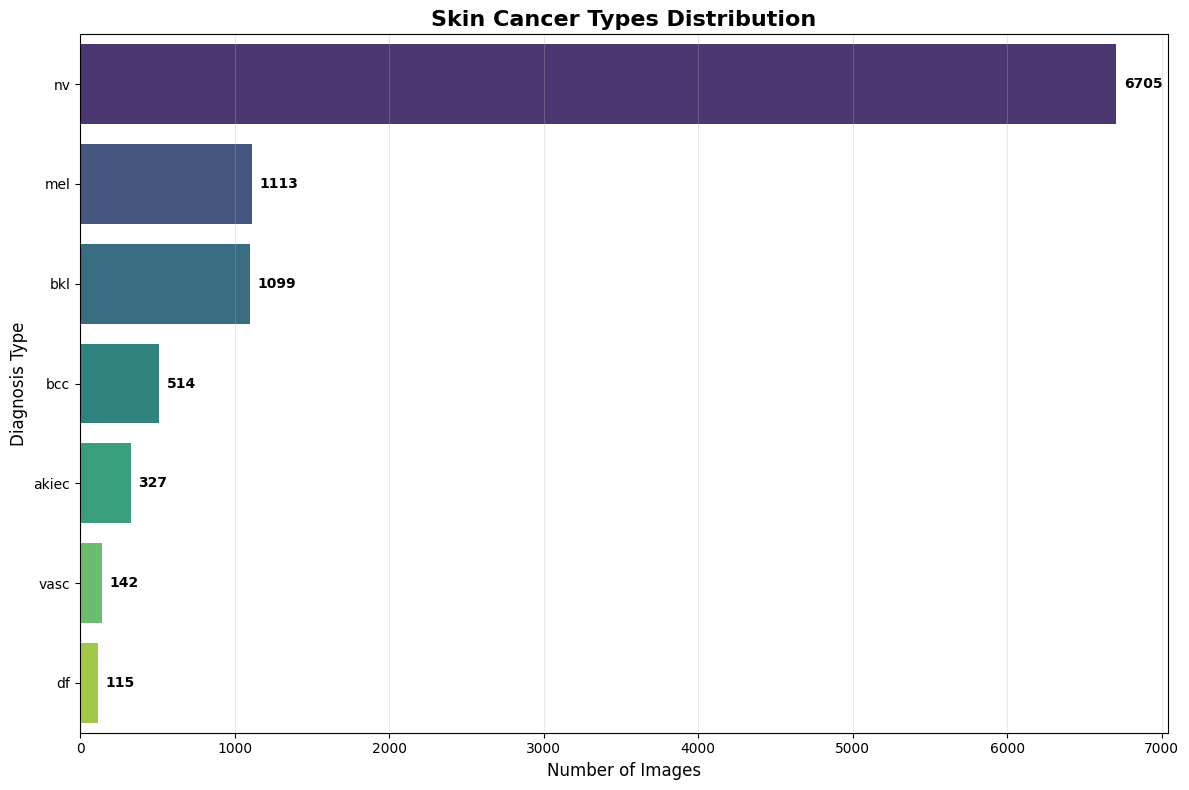

In [7]:
# Fixed version without the warning
plt.figure(figsize=(12, 8))
sns.barplot(x=dx_counts.values, y=dx_counts.index, hue=dx_counts.index, palette='viridis', legend=False)
plt.title('Skin Cancer Types Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Diagnosis Type', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, value in enumerate(dx_counts.values):
    plt.text(value + 50, i, f'{value}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Paths (WSL/Linux format)
image_dir = "/mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_images"
metadata_path = "/mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_metadata.csv"

# Load metadata
metadata = pd.read_csv(metadata_path)

# Prepare dataframe for generator
metadata['filename'] = metadata['image_id'] + '.jpg'
metadata['class'] = metadata['dx']

# Split into train/validation
train_df, val_df = train_test_split(
    metadata, test_size=0.2, stratify=metadata['dx'], random_state=42
)

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory=image_dir,
    x_col='filename',
    y_col='class',
    target_size=(224, 224),  # ResNet50 input size
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    directory=image_dir,
    x_col='filename',
    y_col='class',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)



Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


Original image shape: (450, 600, 3)


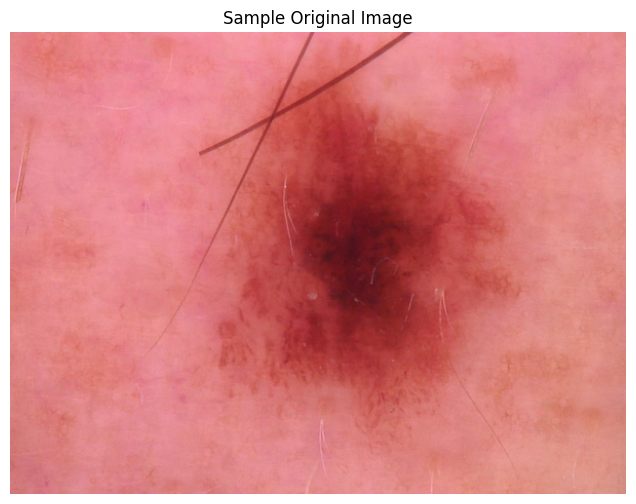

In [9]:
import cv2
import matplotlib.pyplot as plt

# Sample image path (update to your local folder)
sample_image_path = "/mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_images/ISIC_0024306.jpg"

# Load and convert to RGB
img = cv2.imread(sample_image_path)
if img is None:
    print(f"Error: Could not load image from {sample_image_path}")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"Original image shape: {img.shape}")

# Display
if img is not None:
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title('Sample Original Image')
    plt.axis('off')
    plt.show()
else:
    print("Image not loaded, cannot display.")

🔍 Now Let's Compare Both Approaches:

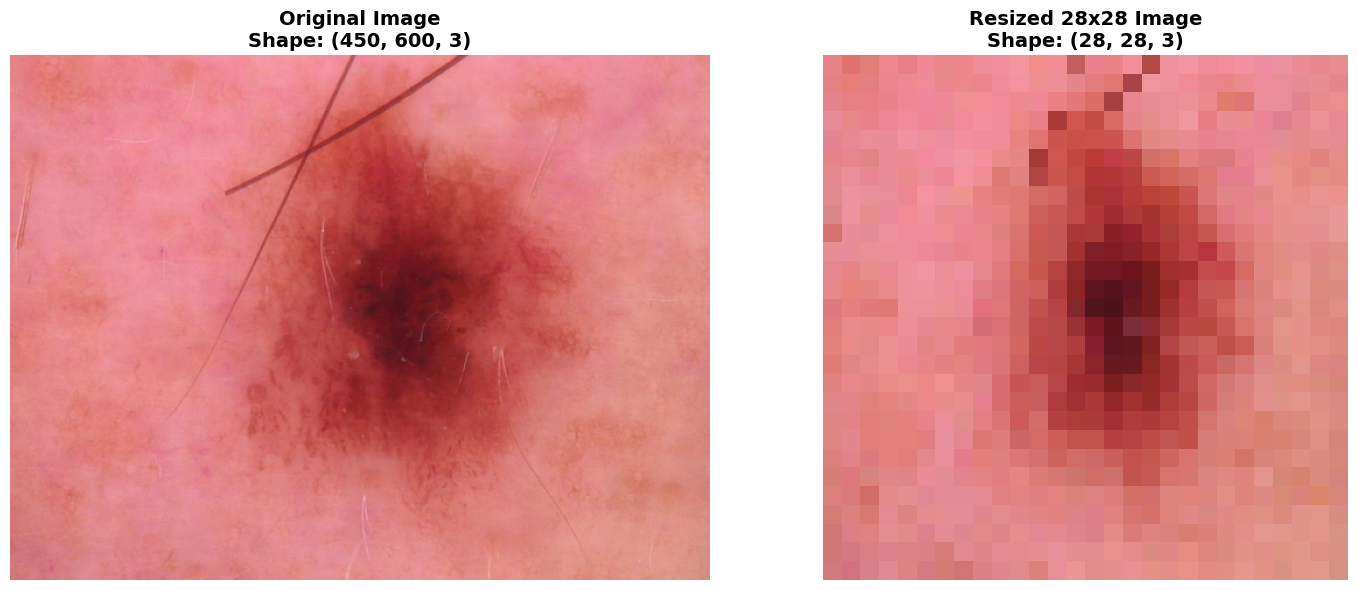

In [10]:
import cv2
import matplotlib.pyplot as plt

# Original image path (Linux/WSL format)
original_path = "/mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_images/ISIC_0024306.jpg"

# Load original image
original_img = cv2.imread(original_path)
if original_img is None:
    print(f"Error: Could not load image from {original_path}")
else:
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Create 28x28 version
    small_img = cv2.resize(original_img, (28, 28))

    # Plot side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    ax1.imshow(original_img)
    ax1.set_title(f'Original Image\nShape: {original_img.shape}', fontsize=14, fontweight='bold')
    ax1.axis('off')

    ax2.imshow(small_img)
    ax2.set_title(f'Resized 28x28 Image\nShape: {small_img.shape}', fontsize=14, fontweight='bold')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

we are using CSV APPROACH as it is :

You're learning and experimenting

You want quick results and iterations

You have limited computational resources

You're prototyping models

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load metadata CSV
metadata_path = "/mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_metadata.csv"
metadata = pd.read_csv(metadata_path)

# Split train/validation
train_df, val_df = train_test_split(
    metadata,
    test_size=0.2,
    random_state=42,
    stratify=metadata['dx']
)

# Compute class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_df['dx']),
    y=train_df['dx']
)
class_weights_dict = dict(zip(np.unique(train_df['dx']), class_weights))

print("Class weights for imbalance handling:")
for class_id, weight in class_weights_dict.items():
    print(f"{class_id}: weight = {weight:.2f}")

# ImageDataGenerators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# These generators will handle batch-wise loading and resizing later (e.g., 224x224 for ResNet50)


Class weights for imbalance handling:
akiec: weight = 4.37
bcc: weight = 2.78
bkl: weight = 1.30
df: weight = 12.44
mel: weight = 1.29
nv: weight = 0.21
vasc: weight = 10.04


as we were wanting to use RESNET50 which works on original image but due to some storage issues will will be using another approach that is:

resizing our CSV file from 28x28 to 224x224

other approaches are also here:
1.making subset of our dataset and can extend it later but the challenge was that i needed to upload thatHAM10000 on my drive which is not practicle soo here we are usning our current approach

NOOOOOOOOOOOOOO
Instead what we will be doing is that we will be rescaling the original to 224 resnet50 format directly in order to avoid unnecessary downgrading the data quality thus maintaining accuracy along with quality

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

# Paths (WSL/Linux format)
metadata_path = "/mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_metadata.csv"
image_dir = "/mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_images"

# 1️⃣ Load metadata
metadata = pd.read_csv(metadata_path)

# 2️⃣ Train/Validation split (stratified)
train_df, val_df = train_test_split(
    metadata,
    test_size=0.2,
    random_state=42,
    stratify=metadata['dx']
)

# 3️⃣ Compute class weights to handle imbalance
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=metadata['dx'].unique(),
    y=train_df['dx']
)
class_weights_dict = dict(zip(metadata['dx'].unique(), class_weights))

print("Class weights:")
for cls, weight in class_weights_dict.items():
    print(f"{cls}: {weight:.2f}")


Class weights:
bkl: 1.30
nv: 0.21
df: 12.44
mel: 1.29
vasc: 10.04
bcc: 2.78
akiec: 4.37


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ensure filenames have the .jpg extension
train_df['image_id'] = train_df['image_id'].apply(lambda x: f"{x}.jpg")
val_df['image_id'] = val_df['image_id'].apply(lambda x: f"{x}.jpg")

# ImageDataGenerators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='image_id',       # column with filenames
    y_col='dx',             # diagnosis/label column
    target_size=(224, 224), # ResNet50 input size
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Validation generator
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='image_id',
    y_col='dx',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Optional: Check classes
print("Classes:", train_generator.class_indices)


Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.
Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


Applying RESNET50 preprocessing now ⚓

In [14]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)


⚓train-test spliting


⚓Calculating class weight

In [15]:
import numpy as np
from sklearn.utils import class_weight

# Compute class weights from train_df
classes = train_df['dx'].unique()
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['dx']
)
class_weights_dict = dict(zip(classes, weights))

print("Class weights:")
for cls, weight in class_weights_dict.items():
    print(f"{cls}: {weight:.2f}")


Class weights:
nv: 0.21
akiec: 4.37
bkl: 1.30
bcc: 2.78
mel: 1.29
vasc: 10.04
df: 12.44


⚓Build and train RESNET50

In [16]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

def build_resnet50_model(num_classes=7):
    """
    Build a ResNet50-based model for classification.
    The base model is frozen by default.
    """
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False  # Freeze base

    # Custom head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# -----------------------------
# Example usage: small subset
# -----------------------------
# Assume X_train_small, y_train_small, X_val_small, y_val_small exist (e.g., 200-500 images)
# model = build_resnet50_model(num_classes=7)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train on small subset first (CPU-safe)
# history = model.fit(
#     X_train_small, y_train_small,
#     validation_data=(X_val_small, y_val_small),
#     epochs=10,
#     batch_size=16,
#     class_weight=class_weights_dict,
#     callbacks=[early_stop, reduce_lr]
# )


⚓Training the Model

In [17]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Physical GPUs:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.14.0
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

# Use existing variables
# image_dir and metadata_path are already defined

# Load metadata
metadata = pd.read_csv(metadata_path)
image_files = metadata['image_id'] + '.jpg'
labels = metadata['dx']

# Encode labels as integers
class_names = sorted(labels.unique())
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
y = labels.map(class_to_idx).values

# Train/test split on file paths
train_files, test_files, y_train, y_test = train_test_split(
    image_files.values, y, test_size=0.2, stratify=y, random_state=42
)

# Preprocessing function for tf.data
def preprocess(filename, label):
    img_path = tf.strings.join([image_dir, '/', filename])
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0  # normalize
    return img, label

# Create tf.data datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_files, y_train))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1024).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_files, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))


2025-09-29 11:16:08.300105: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-29 11:16:08.300268: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-29 11:16:08.300304: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-29 11:16:09.650802: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-09-29 11:16:09.650904: I tensorflow/compile

In [19]:
# Preprocessing function
def preprocess(filename, label):
    img_path = tf.strings.join([image_dir, '/', filename])
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0
    return img, label

# Train/test split
train_files, test_files, y_train, y_test = train_test_split(
    metadata['image_id'].values + '.jpg',
    metadata['dx'].map({cls: idx for idx, cls in enumerate(sorted(metadata['dx'].unique()))}).values,
    test_size=0.2,
    stratify=metadata['dx'].values,
    random_state=42
)

# Create tf.data datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_files, y_train))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1024).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_files, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)


In [20]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights using y_train from the split
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(zip(np.unique(y_train), class_weights))

print("Class Weights:", class_weights_dict)


Class Weights: {0: 4.368593238822246, 1: 2.7848453249913105, 2: 1.3021290427433772, 3: 12.440993788819876, 4: 1.2860353130016051, 5: 0.21338020666879728, 6: 10.040100250626567}


In [21]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights using y_train
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))

print("Class Weights:", class_weights_dict)


Class Weights: {0: 4.368593238822246, 1: 2.7848453249913105, 2: 1.3021290427433772, 3: 12.440993788819876, 4: 1.2860353130016051, 5: 0.21338020666879728, 6: 10.040100250626567}


In [22]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load pre-trained ResNet50 (without top layers)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(7, activation='softmax')(x)  # 7 classes

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

# Show model summary
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                          

In [23]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input

def preprocess_resnet(image, label):
    image = image * 255.0  # scale if images are in [0,1]
    image = preprocess_input(image)
    return image, label

train_ds = train_ds.map(preprocess_resnet)
test_ds = test_ds.map(preprocess_resnet)

# Optional: check a batch
for images, labels in train_ds.take(1):
    min_val = tf.reduce_min(images)
    max_val = tf.reduce_max(images)
    print(f"Processed batch shape: {images.shape}, range: [{min_val.numpy():.3f}, {max_val.numpy():.3f}]")


Processed batch shape: (8, 32, 224, 224, 3), range: [-8068920.000, 9791099.000]


2025-09-29 11:53:07.602593: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]

print("Starting training on full dataset...")

# Train the model on GPU
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1
)

print("Training completed!")


Starting training on full dataset...
Epoch 1/20


2025-09-29 11:16:21.690535: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907
2025-09-29 11:16:30.889617: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x5794d3b3cac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-29 11:16:30.889691: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-09-29 11:16:30.904989: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-29 11:16:31.031222: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


251/251 [==============================] - 61s 182ms/step - loss: 2.0400 - accuracy: 0.1317 - val_loss: 1.9743 - val_accuracy: 0.0140 - lr: 0.0010
Epoch 2/20
251/251 [==============================] - 35s 132ms/step - loss: 1.9490 - accuracy: 0.0509 - val_loss: 1.9555 - val_accuracy: 0.0115 - lr: 0.0010
Epoch 3/20
251/251 [==============================] - 34s 129ms/step - loss: 1.9468 - accuracy: 0.0305 - val_loss: 1.9517 - val_accuracy: 0.0115 - lr: 0.0010
Epoch 4/20
251/251 [==============================] - 34s 131ms/step - loss: 1.9464 - accuracy: 0.0278 - val_loss: 1.9464 - val_accuracy: 0.0514 - lr: 0.0010
Epoch 5/20
251/251 [==============================] - 35s 130ms/step - loss: 1.9463 - accuracy: 0.0308 - val_loss: 1.9454 - val_accuracy: 0.0514 - lr: 0.0010
Epoch 6/20
251/251 [==============================] - 34s 129ms/step - loss: 1.9464 - accuracy: 0.1350 - val_loss: 1.9444 - val_accuracy: 0.0514 - lr: 0.0010
Epoch 7/20
251/251 [==============================] - 34s 129ms

In [26]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.resnet50 import preprocess_input

# Clear any previous models from GPU memory
tf.keras.backend.clear_session()

# Mixed precision (optional but reduces VRAM usage)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Preprocess your datasets
def preprocess_ds(images, labels):
    images = preprocess_input(images * 255.0)  # scale to [0,255] + ResNet50 normalization
    return images, labels

# Apply preprocessing to your tf.data datasets
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(preprocess_ds).batch(8).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(preprocess_ds).batch(8).cache().prefetch(buffer_size=AUTOTUNE)

# Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)
]

print("Starting training on GPU with optimized settings...")

# Train the model
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights_dict,  # keep if you were using it
    verbose=1
)

print("Training completed!")


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6
Starting training on GPU with optimized settings...
Epoch 1/20


2025-09-29 11:23:06.497857: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


TypeError: in user code:

    File "/home/krish/skinvision-env/lib/python3.10/site-packages/keras/src/engine/training.py", line 1377, in train_function  *
        return step_function(self, iterator)
    File "/home/krish/skinvision-env/lib/python3.10/site-packages/keras/src/engine/training.py", line 1360, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/home/krish/skinvision-env/lib/python3.10/site-packages/keras/src/engine/training.py", line 1349, in run_step  **
        outputs = model.train_step(data)
    File "/home/krish/skinvision-env/lib/python3.10/site-packages/keras/src/engine/training.py", line 1131, in train_step
        return self.compute_metrics(x, y, y_pred, sample_weight)
    File "/home/krish/skinvision-env/lib/python3.10/site-packages/keras/src/engine/training.py", line 1225, in compute_metrics
        self.compiled_metrics.update_state(y, y_pred, sample_weight)
    File "/home/krish/skinvision-env/lib/python3.10

In [ ]:
# Let's rebuild the model using a different approach
from tensorflow.keras import Input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Clear any previous models
import tensorflow as tf
tf.keras.backend.clear_session()

# Build model using Functional API
inputs = Input(shape=(224, 224, 3))
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=inputs)

# Freeze base model
base_model.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(7, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

# Try a test prediction first
test_pred = model.predict(X_train_processed[:1])
print(f"Test prediction shape: {test_pred.shape}")
print("Model is working!")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,146,055 (92.11 MB)

 Trainable params: 558,343 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Test prediction shape: (1, 7)
Model is working!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define simpler callbacks (to avoid potential issues)
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=3)
]

print("Starting training with the working model...")
print(f"Training on {X_train_processed.shape[0]} samples")
print(f"Validating on {X_test_processed.shape[0]} samples")

# Train the model
history = model.fit(
    X_train_processed, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test_processed, y_test),
    callbacks=callbacks,
    verbose=1
)

print("Training completed successfully! 🎉")

Starting training with the working model...
Training on 560 samples
Validating on 140 samples
Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 150s 4s/step - accuracy: 0.2003 - loss: 2.5402 - val_accuracy: 0.4429 - val_loss: 1.5599 - learning_rate: 0.0010
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 196s 4s/step - accuracy: 0.3822 - loss: 1.6372 - val_accuracy: 0.4571 - val_loss: 1.4277 - learning_rate: 0.0010
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 143s 4s/step - accuracy: 0.4494 - loss: 1.4349 - val_accuracy: 0.4214 - val_loss: 1.3971 - learning_rate: 0.0010
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.4542 - loss: 1.4552 - val_accuracy: 0.5000 - val_loss: 1.2838 - learning_rate: 0.0010
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.4875 - loss: 1.3234 - val_accuracy: 0.5071 - val_loss: 1.1929 - learning_rate: 0.0010
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.5335 - loss: 1.2025 - val_accuracy: 0.5643 - val_loss: 1.2018 - learning_rate: 0.0010


In [ ]:
from sklearn.model_selection import train_test_split

# Take 28% of the dataset
X_subset, _, y_subset, _ = train_test_split(
    X, y,
    train_size=0.28,   # 28% of data
    stratify=y,        # preserve class distribution
    random_state=42
)

print(f"Subset shape: {X_subset.shape}")
print(f"Labels shape: {y_subset.shape}")

# Verify class distribution
unique, counts = np.unique(y_subset, return_counts=True)
print("\nClass distribution in 28% subset:")
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} images")


Subset shape: (2804, 28, 28, 3)
Labels shape: (2804,)

Class distribution in 28% subset:
Class 0: 91 images
Class 1: 144 images
Class 2: 308 images
Class 3: 32 images
Class 4: 1877 images
Class 5: 40 images
Class 6: 312 images


In [ ]:
import pandas as pd
import numpy as np

# Corrected file path
df = pd.read_csv('HAM10000_dataset/hmnist_28_28_RGB.csv')
X = df.drop('label', axis=1).values.reshape(-1, 28, 28, 3) / 255.0
y = df['label'].values

In [ ]:
# --- Step 1: Preprocess full dataset for ResNet50 ---

import os
import cv2
import numpy as np
import pandas as pd # Import pandas to load metadata
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from PIL import Image, ImageFilter

# Directories containing images
image_dirs = [
    'HAM10000_dataset/HAM10000_images_part_1',
    'HAM10000_dataset/HAM10000_images_part_2'
]

# Load metadata
try:
    metadata = pd.read_csv('HAM10000_dataset/HAM10000_metadata.csv')
except FileNotFoundError:
    print("Error: metadata.csv not found. Make sure the dataset is downloaded and unzipped correctly.")
    metadata = None # Set metadata to None to avoid errors later

# Initialize lists
X = []
y = []

# Loop through metadata and load images
if metadata is not None:
    for idx, row in metadata.iterrows():
        img_id = row['image_id'] + '.jpg'
        label = row['dx']

        for d in image_dirs:
            img_path = os.path.join(d, img_id)
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (224, 224))  # Resize for ResNet50

                    # Apply sharpening filter
                    pil_img = Image.fromarray(img)
                    sharpened_img = pil_img.filter(ImageFilter.SHARPEN)
                    img_array = np.array(sharpened_img)

                    X.append(img_array)
                    y.append(label)
                    break
                else:
                    print(f"Warning: Could not read image file: {img_path}")


    # Convert to arrays and normalize
    X = np.array(X) / 255.0
    y = np.array(y)

    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    y_onehot = to_categorical(y_encoded)

    print(f"Full dataset loaded: {X.shape} images, {y_onehot.shape} labels")

    # --- Save the preprocessed images and labels ---
    output_dir = 'preprocessed_ham10000'
    os.makedirs(output_dir, exist_ok=True)

    # Save images (as numpy array)
    np.save(os.path.join(output_dir, 'X_224_preprocessed.npy'), X)

    # Save labels (both encoded and one-hot)
    np.save(os.path.join(output_dir, 'y_encoded.npy'), y_encoded)
    np.save(os.path.join(output_dir, 'y_onehot.npy'), y_onehot)
    np.save(os.path.join(output_dir, 'y_original_labels.npy'), y) # Save original labels for reference

    print(f"\nPreprocessed data saved to '{output_dir}/'")
    print(f"- X_224_preprocessed.npy")
    print(f"- y_encoded.npy")
    print(f"- y_onehot.npy")
    print(f"- y_original_labels.npy")

else:
    print("Skipping data loading and preprocessing due to metadata error.")